<a href="https://colab.research.google.com/github/mubarak-byte/post-theft-ussd-fraud-detection/blob/main/USSD_fraud_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ============================================
#
# Nigerian Post-Theft USSD Fraud Detection
# ============================================

# ── CELL 1 — Install libraries ──
!pip install imbalanced-learn xgboost lightgbm --quiet
print(" Libraries installed!")

# ── CELL 2 — Imports ──
import numpy as np
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest, RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score,
                             recall_score, f1_score,
                             roc_auc_score, confusion_matrix,
                             classification_report)
from sklearn.utils.class_weight import compute_class_weight
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
import time
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
tf.random.set_seed(42)
print(" Imports done!")

✅ Libraries installed!
✅ Imports done!


In [ ]:
# ============================================
# CELL 3 — Dataset Generation v10 (Patches 1-10 applied)
# - All previous calibration improvements
# - Patches 7-10: structural time/novelty/txn_type separators broken
# ============================================

LEGIT_HOURS = [8,8,9,9,9,10,10,10,11,11,12,12,13,
               13,14,14,15,15,16,16,17,17,18,18,19,
               19,20,20,21,22]

FRAUD_HOURS = [0,1,1,2,2,3,3,4,22,22,23,23,
               9,10,11,12,13,14]

NO_PIN_RESET = 999999

def create_user_profile(user_id):
    return {
        'user_id': user_id,
        'typical_hour': np.random.choice(LEGIT_HOURS),
        'typical_amount': np.random.uniform(500, 20000),
        'typical_velocity': np.random.uniform(0.5, 2.0),
        'bvn_active': np.random.random() < 0.20,
        'recent_legit_pin_reset_mins': (
            NO_PIN_RESET if np.random.random() > 0.05
            else np.random.uniform(1440, 10080)
        ),
    }

def make_legit_txn(profile, txn_id):
    if np.random.random() < 0.10:
        hour = np.random.randint(0, 6)
    else:
        hour = profile['typical_hour'] + np.random.randint(-3, 4)
        hour = max(0, min(23, hour))

    if np.random.random() < 0.12:
        amount = np.random.uniform(50000, 200000)
    else:
        amount = profile['typical_amount'] * np.random.uniform(0.2, 4.0)
    amount = round(abs(amount), 2)

    amount_dev = (amount - profile['typical_amount']) / (profile['typical_amount'] + 1)
    amount_dev = max(-5, min(5, amount_dev))

    if np.random.random() < 0.05:
        velocity = np.random.uniform(4, 8)
    else:
        velocity = profile['typical_velocity'] * np.random.uniform(0.3, 2.5)

    daily_prox = min(amount / 200000, 1.0) * np.random.uniform(0.5, 1.5)
    imei = int(np.random.random() > 0.08)
    location = int(np.random.random() < 0.25)
    recipient_novelty = int(np.random.random() < 0.25)

    alert_number_match = int(np.random.random() < 0.98)

    if profile['bvn_active']:
        bvn_check = int(np.random.random() < 0.25)
        account_check = int(np.random.random() < 0.40)
    else:
        bvn_check = int(np.random.random() < 0.08)
        account_check = int(np.random.random() < 0.20)

    dob_extracted = int(np.random.random() < 0.06)
    pin_reset = int(np.random.random() < 0.05)

    if pin_reset == 1:
        time_since_pin_reset = round(np.random.uniform(0.5, 5), 2)
    else:
        time_since_pin_reset = profile['recent_legit_pin_reset_mins']

    session_anomaly = int(np.random.random() < 0.18)
    intermediate_account = int(np.random.random() < 0.25)
    layered_transfer = int(np.random.random() < 0.12)

    rt_rand = np.random.random()
    if rt_rand < 0.70:
        recipient_type = 'Known'
    elif rt_rand < 0.90:
        recipient_type = 'Merchant'
    else:
        recipient_type = 'POS_Unknown'

    tt_rand = np.random.random()
    if tt_rand < 0.60:
        txn_type = 'Transfer'
    elif tt_rand < 0.85:
        txn_type = 'Airtime'
    else:
        txn_type = 'BillPayment'

    return {
        'user_id': profile['user_id'],
        'txn_id': txn_id,
        'transaction_hour': hour,
        'imei_match': imei,
        'location_anomaly': location,
        'txn_amount': amount,
        'amount_deviation': amount_dev,
        'recipient_novelty': recipient_novelty,
        'velocity_score': round(velocity, 4),
        # PATCH 9: 35% rapid legit (was 20%)
        'time_since_last_txn': np.random.choice([
            np.random.uniform(0.1, 2),
            np.random.uniform(2, 96)
        ], p=[0.35, 0.65]),
        'daily_limit_proximity': round(min(daily_prox, 1.0), 4),
        'cumulative_session_amt': round(amount * np.random.uniform(1.0, 1.5), 2),
        'alert_number_match': alert_number_match,
        'account_check_flag': account_check,
        'bvn_check_flag': bvn_check,
        'dob_extracted_flag': dob_extracted,
        'pin_reset_flag': pin_reset,
        'time_since_pin_reset': time_since_pin_reset,
        'session_anomaly': session_anomaly,
        'intermediate_account': intermediate_account,
        'layered_transfer': layered_transfer,
        'recipient_type': recipient_type,
        'txn_type': txn_type,
        'is_fraud': 0
    }

def make_fraud_txn(profile, txn_id, phase, cumulative, session_pin_mins):
    hour = np.random.choice(FRAUD_HOURS)

    # PATCH 7: Phase 1 - gap between victim's last legit and theft can be hours/days
    if phase == 1:
        amount = np.random.uniform(50, 500)
        velocity = np.random.uniform(0.5, 2.5)
        recipient_novelty = int(np.random.random() > 0.3)
        time_gap = np.random.choice([
            np.random.uniform(0.1, 6),
            np.random.uniform(6, 24),
            np.random.uniform(24, 168)
        ], p=[0.60, 0.25, 0.15])
    elif phase == 2:
        amount = np.random.uniform(10, 100)
        velocity = np.random.uniform(1, 3)
        recipient_novelty = int(np.random.random() > 0.2)
        time_gap = np.random.uniform(0.02, 1.5)
    elif phase == 3:
        amount = np.random.uniform(0, 50)
        velocity = np.random.uniform(2, 5)
        recipient_novelty = 1
        time_gap = np.random.uniform(0.02, 1.0)
    # PATCH 8 + 9: Phase 4 patient attackers + reduced novelty
    elif phase == 4:
        if np.random.random() < 0.40:
            amount = np.random.uniform(1000, 20000)
        else:
            amount = np.random.uniform(20000, 150000)
        velocity = np.random.uniform(2, 7)
        recipient_novelty = int(np.random.random() < 0.80)
        if np.random.random() < 0.20:
            time_gap = np.random.uniform(2, 12)
        else:
            time_gap = np.random.uniform(0.02, 1.5)
    # PATCH 8 + 9: Phase 5 patient attackers + reduced novelty
    else:
        amount = np.random.uniform(1000, 40000)
        velocity = np.random.uniform(3, 8)
        recipient_novelty = int(np.random.random() < 0.75)
        if np.random.random() < 0.15:
            time_gap = np.random.uniform(1, 8)
        else:
            time_gap = np.random.uniform(0.02, 1.0)

    amount_dev = (amount - profile['typical_amount']) / (profile['typical_amount'] + 1)
    amount_dev = max(-5, min(5, amount_dev))
    daily_prox = min((cumulative + amount) / 200000, 1.0)
    imei = int(np.random.random() > 0.75)
    location = int(np.random.random() > 0.40)

    alert_number_match = 1

    if phase == 2:
        account_check = int(np.random.random() < 0.75)
        bvn_check = int(np.random.random() < 0.75)
        dob_extracted = int(np.random.random() < 0.55)
    else:
        account_check = int(np.random.random() < 0.10)
        bvn_check = int(np.random.random() < 0.05)
        dob_extracted = int(np.random.random() < 0.05)

    if phase == 3:
        pin_reset = 1
        time_since_pin_reset = round(np.random.uniform(0.5, 2), 2)
    elif phase in [4, 5]:
        pin_reset = 0
        time_since_pin_reset = session_pin_mins
    else:
        pin_reset = 0
        time_since_pin_reset = NO_PIN_RESET

    session_anomaly = int(np.random.random() < 0.65)

    if phase in [4, 5]:
        intermediate_account = int(np.random.random() < 0.65)
    else:
        intermediate_account = int(np.random.random() < 0.20)

    if phase == 5:
        layered_transfer = int(np.random.random() < 0.65)
    elif phase == 4:
        layered_transfer = int(np.random.random() < 0.30)
    else:
        layered_transfer = int(np.random.random() < 0.05)

    if phase in [4, 5]:
        rt_rand = np.random.random()
        if rt_rand < 0.55:
            recipient_type = 'POS_Unknown'
        elif rt_rand < 0.85:
            recipient_type = 'Merchant'
        else:
            recipient_type = 'Known'
    else:
        rt_rand = np.random.random()
        if rt_rand < 0.50:
            recipient_type = 'POS_Unknown'
        elif rt_rand < 0.80:
            recipient_type = 'Merchant'
        else:
            recipient_type = 'Known'

    # PATCH 10: 8% bill payment for fraud (mule airtime, bills)
    if phase in [1, 2, 3]:
        txn_type = 'Airtime' if np.random.random() < 0.80 else 'Transfer'
    else:
        tt_rand = np.random.random()
        if tt_rand < 0.80:
            txn_type = 'Transfer'
        elif tt_rand < 0.92:
            txn_type = 'Airtime'
        else:
            txn_type = 'BillPayment'

    return {
        'user_id': profile['user_id'],
        'txn_id': txn_id,
        'transaction_hour': hour,
        'imei_match': imei,
        'location_anomaly': location,
        'txn_amount': round(amount, 2),
        'amount_deviation': round(amount_dev, 4),
        'recipient_novelty': recipient_novelty,
        'velocity_score': round(velocity, 4),
        'time_since_last_txn': round(time_gap, 4),
        'daily_limit_proximity': round(daily_prox, 4),
        'cumulative_session_amt': round(cumulative + amount, 2),
        'alert_number_match': alert_number_match,
        'account_check_flag': account_check,
        'bvn_check_flag': bvn_check,
        'dob_extracted_flag': dob_extracted,
        'pin_reset_flag': pin_reset,
        'time_since_pin_reset': time_since_pin_reset,
        'session_anomaly': session_anomaly,
        'intermediate_account': intermediate_account,
        'layered_transfer': layered_transfer,
        'recipient_type': recipient_type,
        'txn_type': txn_type,
        'is_fraud': 1
    }, amount

# ============================================
# Generate dataset
# ============================================
print("="*55)
print("Generating Nigerian USSD Dataset v10 (Patches 1-10)")
print("="*55)

all_transactions = []
txn_id = 0
n_users = 1000
fraud_victim_rate = 0.35
fraud_users = 0
legit_count = 0
fraud_count = 0

for user_id in range(n_users):
    profile = create_user_profile(user_id)
    is_victim = np.random.random() < fraud_victim_rate

    n_legit_before = np.random.randint(25, 60)
    for _ in range(n_legit_before):
        all_transactions.append(make_legit_txn(profile, txn_id))
        txn_id += 1
        legit_count += 1

    if is_victim:
        fraud_users += 1
        cumulative = 0
        session_pin_mins = NO_PIN_RESET

        txn, amt = make_fraud_txn(profile, txn_id, 1, cumulative, session_pin_mins)
        all_transactions.append(txn); txn_id += 1; fraud_count += 1; cumulative += amt

        if np.random.random() > 0.10:
            txn, amt = make_fraud_txn(profile, txn_id, 2, cumulative, session_pin_mins)
            all_transactions.append(txn); txn_id += 1; fraud_count += 1; cumulative += amt

        if np.random.random() > 0.05:
            txn, amt = make_fraud_txn(profile, txn_id, 3, cumulative, session_pin_mins)
            all_transactions.append(txn); txn_id += 1; fraud_count += 1; cumulative += amt
            session_pin_mins = round(np.random.uniform(1, 5), 2)

        for _ in range(np.random.randint(1, 4)):
            txn, amt = make_fraud_txn(profile, txn_id, 4, cumulative, session_pin_mins)
            all_transactions.append(txn); txn_id += 1; fraud_count += 1; cumulative += amt
            if session_pin_mins != NO_PIN_RESET:
                session_pin_mins += round(np.random.uniform(2, 8), 2)

        if np.random.random() > 0.10:
            txn, amt = make_fraud_txn(profile, txn_id, 5, cumulative, session_pin_mins)
            all_transactions.append(txn); txn_id += 1; fraud_count += 1; cumulative += amt

        n_legit_after = np.random.randint(5, 20)
        for _ in range(n_legit_after):
            all_transactions.append(make_legit_txn(profile, txn_id))
            txn_id += 1; legit_count += 1
    else:
        n_extra = np.random.randint(10, 25)
        for _ in range(n_extra):
            all_transactions.append(make_legit_txn(profile, txn_id))
            txn_id += 1; legit_count += 1

df7 = pd.DataFrame(all_transactions)

df7 = pd.get_dummies(df7, columns=['recipient_type', 'txn_type'],
                     prefix=['recipient', 'txn_type'], drop_first=False)
for col in df7.columns:
    if df7[col].dtype == bool:
        df7[col] = df7[col].astype(int)

print(f"\nDATASET v10 SUMMARY")
print(f"{'='*55}")
print(f"Total users:    {n_users}")
print(f"Fraud victims:  {fraud_users} ({fraud_users/n_users*100:.1f}%)")
print(f"Total records:  {len(df7):,}")
print(f"Legitimate:     {legit_count:,}")
print(f"Fraudulent:     {fraud_count:,}")
print(f"Fraud rate:     {fraud_count/len(df7)*100:.2f}%")
print(f"Total columns:  {df7.shape[1]}")
print(f"Missing values: {df7.isnull().sum().sum()}")

feat_cols = [c for c in df7.columns if c not in ['user_id', 'txn_id', 'is_fraud']]

print(f"\nFeature count after one-hot encoding: {len(feat_cols)}")
print(f"\nFeature overlap check (target: 1.5x – 15x ratio):")
print(f"{'Feature':<32} {'Legit':>10} {'Fraud':>10} {'Ratio':>10}  Status")
print(f"{'-'*78}")

for feat in feat_cols:
    legit_mean = df7[df7['is_fraud']==0][feat].mean()
    fraud_mean = df7[df7['is_fraud']==1][feat].mean()
    ratio = fraud_mean / (legit_mean + 0.001)

    if ratio > 20:
        status = "🔴 too high"
    elif ratio > 15:
        status = "🟡 high"
    elif ratio >= 1.5:
        status = "✅ good signal"
    elif ratio >= 0.5:
        status = "✅ low signal"
    else:
        status = "✅ inverse signal"

    print(f"{feat:<32} {legit_mean:>10.3f} {fraud_mean:>10.3f} {ratio:>10.1f}x  {status}")

df7.to_csv('ussd_fraud_dataset_v10.csv', index=False)
print(f"\n✅ Dataset v10 saved.")

Generating Nigerian USSD Dataset v10 (Patches 1-10)

DATASET v10 SUMMARY
Total users:    1000
Fraud victims:  362 (36.2%)
Total records:  58,996
Legitimate:     56,918
Fraudulent:     2,078
Fraud rate:     3.52%
Total columns:  28
Missing values: 0

Feature count after one-hot encoding: 25

Feature overlap check (target: 1.5x – 15x ratio):
Feature                               Legit      Fraud      Ratio  Status
------------------------------------------------------------------------------
transaction_hour                     12.946      9.689        0.7x  ✅ low signal
imei_match                            0.919      0.249        0.3x  ✅ inverse signal
location_anomaly                      0.252      0.588        2.3x  ✅ good signal
txn_amount                        34430.704  21635.476        0.6x  ✅ low signal
amount_deviation                      1.553      0.721        0.5x  ✅ inverse signal
recipient_novelty                     0.250      0.807        3.2x  ✅ good signal
velocity_

In [ ]:

# ============================================
# CELL 4 — Preprocessing setup (v7)
# - Clip time_since_pin_reset sentinel
# - GroupKFold by user_id (no user leakage)
# - No SMOTE here — happens per-fold inside Cell 5
# ============================================

from sklearn.model_selection import GroupKFold

# Clip the sentinel so it doesn't dominate scaling
# 43200 mins = 30 days. Anything >30 days = "no recent reset"
df7['time_since_pin_reset'] = df7['time_since_pin_reset'].clip(upper=43200)

# Features, label, groups
exclude = ['user_id', 'txn_id', 'is_fraud']
feat_cols = [c for c in df7.columns if c not in exclude]
X = df7[feat_cols].values
y = df7['is_fraud'].values
groups = df7['user_id'].values

print(f"Features used: {len(feat_cols)}")
print(f"Total samples: {len(X):,}")
print(f"Fraud rate:    {y.mean()*100:.2f}%")

# Setup 5-fold GroupKFold
N_FOLDS = 5
gkf = GroupKFold(n_splits=N_FOLDS)

# Verify fold composition — no user should appear in both train and test
print(f"\nFold composition check:")
print(f"{'Fold':<6} {'Train users':>13} {'Test users':>13} "
      f"{'Train fraud':>13} {'Test fraud':>13} {'User overlap':>14}")
print("-"*78)
for fold_idx, (tr, te) in enumerate(gkf.split(X, y, groups), 1):
    n_tr_u = len(np.unique(groups[tr]))
    n_te_u = len(np.unique(groups[te]))
    overlap = len(set(groups[tr]) & set(groups[te]))
    tr_fr = y[tr].mean() * 100
    te_fr = y[te].mean() * 100
    print(f"{fold_idx:<6} {n_tr_u:>13} {n_te_u:>13} "
          f"{tr_fr:>12.2f}% {te_fr:>12.2f}% {overlap:>14}")

print(f"\n✅ Preprocessing setup complete. {N_FOLDS} folds ready.")


Features used: 25
Total samples: 58,996
Fraud rate:    3.52%

Fold composition check:
Fold     Train users    Test users   Train fraud    Test fraud   User overlap
------------------------------------------------------------------------------
1                800           200         3.60%         3.21%              0
2                800           200         3.38%         4.09%              0
3                800           200         3.50%         3.63%              0
4                800           200         3.53%         3.47%              0
5                800           200         3.60%         3.20%              0

✅ Preprocessing setup complete. 5 folds ready.


In [ ]:
# ============================================
# CELL 5 — Tree-based models with 5-fold GroupKFold CV
# Models: Isolation Forest, Random Forest, XGBoost, LightGBM
# - SMOTE applied per-fold (training only)
# - Isolation Forest trained on UN-SMOTEd data (unsupervised)
# - Scaler fit on un-SMOTEd training data
# - NO class_weight / scale_pos_weight / is_unbalance (SMOTE handles balance)
# ============================================

def safe_fpr(cm):
    if cm.shape == (2,2):
        tn, fp = cm[0][0], cm[0][1]
        return fp/(tn+fp) if (tn+fp) > 0 else 0.0
    return 0.0

def safe_auc(y_true, y_score):
    try:
        return roc_auc_score(y_true, y_score)
    except:
        return 0.5

def record(model_name, results, y_true, y_pred, y_prob):
    cm = confusion_matrix(y_true, y_pred)
    results[model_name]['accuracy'].append(accuracy_score(y_true, y_pred))
    results[model_name]['precision'].append(precision_score(y_true, y_pred, zero_division=0))
    results[model_name]['recall'].append(recall_score(y_true, y_pred, zero_division=0))
    results[model_name]['f1'].append(f1_score(y_true, y_pred, zero_division=0))
    results[model_name]['auc'].append(safe_auc(y_true, y_prob))
    results[model_name]['fpr'].append(safe_fpr(cm))

models = ['Isolation Forest', 'Random Forest', 'XGBoost', 'LightGBM']
metrics = ['accuracy', 'precision', 'recall', 'f1', 'auc', 'fpr']
fold_results = {m: {k: [] for k in metrics} for m in models}

print("="*70)
print("5-fold GroupKFold cross-validation (tree-based models)")
print("="*70)

for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X, y, groups), 1):
    print(f"\n── Fold {fold_idx}/{N_FOLDS} ──")
    X_tr_raw, X_te_raw = X[tr_idx], X[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    # Scaler fitted on un-SMOTEd training data
    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_raw)
    X_te_sc = scaler.transform(X_te_raw)

    # SMOTE on scaled training data ONLY
    smote = SMOTE(random_state=42, k_neighbors=5)
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sc, y_tr)

    # ── Isolation Forest (un-SMOTEd) ──
    iso = IsolationForest(
        contamination=max(y_tr.mean(), 0.01),
        n_estimators=200,
        max_samples=256,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_tr_sc)
    y_pred = (iso.predict(X_te_sc) == -1).astype(int)
    y_prob = -iso.score_samples(X_te_sc)
    record('Isolation Forest', fold_results, y_te, y_pred, y_prob)
    print(f"  IF:  AUC={fold_results['Isolation Forest']['auc'][-1]:.4f} "
          f"F1={fold_results['Isolation Forest']['f1'][-1]:.4f}")

    # ── Random Forest ──
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr_bal, y_tr_bal)
    y_pred = rf.predict(X_te_sc)
    y_prob = rf.predict_proba(X_te_sc)[:,1]
    record('Random Forest', fold_results, y_te, y_pred, y_prob)
    print(f"  RF:  AUC={fold_results['Random Forest']['auc'][-1]:.4f} "
          f"F1={fold_results['Random Forest']['f1'][-1]:.4f}")

    # ── XGBoost ──
    xgb_model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        min_child_weight=5,
        gamma=0,
        reg_alpha=0.1,
        reg_lambda=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=-1
    )
    xgb_model.fit(X_tr_bal, y_tr_bal)
    y_pred = xgb_model.predict(X_te_sc)
    y_prob = xgb_model.predict_proba(X_te_sc)[:,1]
    record('XGBoost', fold_results, y_te, y_pred, y_prob)
    print(f"  XGB: AUC={fold_results['XGBoost']['auc'][-1]:.4f} "
          f"F1={fold_results['XGBoost']['f1'][-1]:.4f}")

    # ── LightGBM ──
    lgbm = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    lgbm.fit(X_tr_bal, y_tr_bal)
    y_pred = lgbm.predict(X_te_sc)
    y_prob = lgbm.predict_proba(X_te_sc)[:,1]
    record('LightGBM', fold_results, y_te, y_pred, y_prob)
    print(f"  LGB: AUC={fold_results['LightGBM']['auc'][-1]:.4f} "
          f"F1={fold_results['LightGBM']['f1'][-1]:.4f}")

# ============================================
# Aggregate results — mean ± std across folds
# ============================================
print("\n" + "="*80)
print("CROSS-VALIDATED RESULTS — Tree-Based Models (Mean ± Std, 5 folds)")
print("="*80)
print(f"{'Model':<20} {'Accuracy':>14} {'Precision':>14} {'Recall':>14}")
print("-"*80)
for m in models:
    r = fold_results[m]
    print(f"{m:<20} "
          f"{np.mean(r['accuracy']):.4f}±{np.std(r['accuracy']):.4f} "
          f"{np.mean(r['precision']):.4f}±{np.std(r['precision']):.4f} "
          f"{np.mean(r['recall']):.4f}±{np.std(r['recall']):.4f}")
print(f"\n{'Model':<20} {'F1':>14} {'AUC':>14} {'FPR':>14}")
print("-"*80)
for m in models:
    r = fold_results[m]
    print(f"{m:<20} "
          f"{np.mean(r['f1']):.4f}±{np.std(r['f1']):.4f} "
          f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f} "
          f"{np.mean(r['fpr']):.4f}±{np.std(r['fpr']):.4f}")

# Save for later (LSTM cell will add to this)
import pickle
with open('fold_results_tree.pkl', 'wb') as f:
    pickle.dump(fold_results, f)
# Save scaler and last fold's RF for feature importance plot
import joblib
joblib.dump(rf, 'last_fold_rf.joblib')
joblib.dump(scaler, 'last_fold_scaler.joblib')
print("\n✅ Tree-based CV complete. Results saved.")

5-fold GroupKFold cross-validation (tree-based models)

── Fold 1/5 ──
  IF:  AUC=0.9604 F1=0.5417
  RF:  AUC=0.9999 F1=0.9813
  XGB: AUC=1.0000 F1=0.9842
  LGB: AUC=1.0000 F1=0.9840

── Fold 2/5 ──
  IF:  AUC=0.9624 F1=0.5573
  RF:  AUC=0.9998 F1=0.9855
  XGB: AUC=1.0000 F1=0.9877
  LGB: AUC=0.9999 F1=0.9907

── Fold 3/5 ──
  IF:  AUC=0.9525 F1=0.5368
  RF:  AUC=0.9996 F1=0.9823
  XGB: AUC=0.9998 F1=0.9824
  LGB: AUC=0.9997 F1=0.9847

── Fold 4/5 ──
  IF:  AUC=0.9608 F1=0.5235
  RF:  AUC=0.9995 F1=0.9804
  XGB: AUC=0.9996 F1=0.9781
  LGB: AUC=0.9997 F1=0.9854

── Fold 5/5 ──
  IF:  AUC=0.9577 F1=0.5598
  RF:  AUC=0.9999 F1=0.9895
  XGB: AUC=1.0000 F1=0.9895
  LGB: AUC=0.9999 F1=0.9921

CROSS-VALIDATED RESULTS — Tree-Based Models (Mean ± Std, 5 folds)
Model                      Accuracy      Precision         Recall
--------------------------------------------------------------------------------
Isolation Forest     0.9680±0.0015 0.5460±0.0345 0.5447±0.0313
Random Forest        0.9989±

In [ ]:
# ============================================
# CELL 6 — Experiment 2: USSD-specific features only
# Same models, same CV, restricted feature set
# Tests whether USSD-specific signals alone are sufficient
# ============================================

# USSD-specific feature subset (8 features from threat model)
ussd_specific_features = [
    'bvn_check_flag',
    'account_check_flag',
    'dob_extracted_flag',
    'pin_reset_flag',
    'time_since_pin_reset',
    'session_anomaly',
    'intermediate_account',
    'layered_transfer',
]

# Verify all features exist in df7
missing = [f for f in ussd_specific_features if f not in df7.columns]
if missing:
    raise ValueError(f"Missing features: {missing}")

X_ussd = df7[ussd_specific_features].values
y = df7['is_fraud'].values
groups = df7['user_id'].values

print(f"Experiment 2 — USSD-specific features only")
print(f"Feature count: {len(ussd_specific_features)}")
print(f"Features: {ussd_specific_features}")
print(f"Total samples: {len(X_ussd):,}")
print(f"Fraud rate:    {y.mean()*100:.2f}%")

# Track results separately from Experiment 1
fold_results_ussd = {m: {k: [] for k in metrics} for m in models}

print("\n" + "="*70)
print("EXPERIMENT 2 — 5-fold GroupKFold CV (USSD-only features)")
print("="*70)

for fold_idx, (tr_idx, te_idx) in enumerate(gkf.split(X_ussd, y, groups), 1):
    print(f"\n── Fold {fold_idx}/{N_FOLDS} ──")
    X_tr_raw, X_te_raw = X_ussd[tr_idx], X_ussd[te_idx]
    y_tr, y_te = y[tr_idx], y[te_idx]

    scaler = StandardScaler()
    X_tr_sc = scaler.fit_transform(X_tr_raw)
    X_te_sc = scaler.transform(X_te_raw)

    smote = SMOTE(random_state=42, k_neighbors=5)
    X_tr_bal, y_tr_bal = smote.fit_resample(X_tr_sc, y_tr)

    # ── Isolation Forest ──
    iso = IsolationForest(
        contamination=max(y_tr.mean(), 0.01),
        n_estimators=200,
        max_samples=256,
        random_state=42,
        n_jobs=-1
    )
    iso.fit(X_tr_sc)
    y_pred = (iso.predict(X_te_sc) == -1).astype(int)
    y_prob = -iso.score_samples(X_te_sc)
    record('Isolation Forest', fold_results_ussd, y_te, y_pred, y_prob)
    print(f"  IF:  AUC={fold_results_ussd['Isolation Forest']['auc'][-1]:.4f} "
          f"F1={fold_results_ussd['Isolation Forest']['f1'][-1]:.4f}")

    # ── Random Forest ──
    rf = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=5,
        min_samples_split=10,
        max_features='sqrt',
        random_state=42,
        n_jobs=-1
    )
    rf.fit(X_tr_bal, y_tr_bal)
    y_pred = rf.predict(X_te_sc)
    y_prob = rf.predict_proba(X_te_sc)[:,1]
    record('Random Forest', fold_results_ussd, y_te, y_pred, y_prob)
    print(f"  RF:  AUC={fold_results_ussd['Random Forest']['auc'][-1]:.4f} "
          f"F1={fold_results_ussd['Random Forest']['f1'][-1]:.4f}")

    # ── XGBoost ──
    xgb_model = XGBClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        min_child_weight=5,
        gamma=0,
        reg_alpha=0.1,
        reg_lambda=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        eval_metric='logloss',
        verbosity=0,
        n_jobs=-1
    )
    xgb_model.fit(X_tr_bal, y_tr_bal)
    y_pred = xgb_model.predict(X_te_sc)
    y_prob = xgb_model.predict_proba(X_te_sc)[:,1]
    record('XGBoost', fold_results_ussd, y_te, y_pred, y_prob)
    print(f"  XGB: AUC={fold_results_ussd['XGBoost']['auc'][-1]:.4f} "
          f"F1={fold_results_ussd['XGBoost']['f1'][-1]:.4f}")

    # ── LightGBM ──
    lgbm = LGBMClassifier(
        n_estimators=200,
        learning_rate=0.1,
        max_depth=6,
        num_leaves=31,
        min_child_samples=20,
        reg_alpha=0.1,
        reg_lambda=1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        verbosity=-1,
        n_jobs=-1
    )
    lgbm.fit(X_tr_bal, y_tr_bal)
    y_pred = lgbm.predict(X_te_sc)
    y_prob = lgbm.predict_proba(X_te_sc)[:,1]
    record('LightGBM', fold_results_ussd, y_te, y_pred, y_prob)
    print(f"  LGB: AUC={fold_results_ussd['LightGBM']['auc'][-1]:.4f} "
          f"F1={fold_results_ussd['LightGBM']['f1'][-1]:.4f}")

# ============================================
# Aggregate Experiment 2 results
# ============================================
print("\n" + "="*80)
print("EXPERIMENT 2 RESULTS — USSD-Specific Features Only (Mean ± Std, 5 folds)")
print("="*80)
print(f"{'Model':<20} {'Accuracy':>14} {'Precision':>14} {'Recall':>14}")
print("-"*80)
for m in models:
    r = fold_results_ussd[m]
    print(f"{m:<20} "
          f"{np.mean(r['accuracy']):.4f}±{np.std(r['accuracy']):.4f} "
          f"{np.mean(r['precision']):.4f}±{np.std(r['precision']):.4f} "
          f"{np.mean(r['recall']):.4f}±{np.std(r['recall']):.4f}")
print(f"\n{'Model':<20} {'F1':>14} {'AUC':>14} {'FPR':>14}")
print("-"*80)
for m in models:
    r = fold_results_ussd[m]
    print(f"{m:<20} "
          f"{np.mean(r['f1']):.4f}±{np.std(r['f1']):.4f} "
          f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f} "
          f"{np.mean(r['fpr']):.4f}±{np.std(r['fpr']):.4f}")

# ============================================
# Side-by-side comparison: Experiment 1 vs Experiment 2
# ============================================
print("\n" + "="*80)
print("EXPERIMENT 1 vs EXPERIMENT 2 — AUC Comparison")
print("="*80)
print(f"{'Model':<20} {'Exp 1 (Full)':>18} {'Exp 2 (USSD only)':>20} {'Δ AUC':>10}")
print("-"*80)
for m in models:
    auc1 = np.mean(fold_results[m]['auc'])
    auc2 = np.mean(fold_results_ussd[m]['auc'])
    delta = auc1 - auc2
    print(f"{m:<20} {auc1:>15.4f}    {auc2:>15.4f}    {delta:>+8.4f}")

# Save
with open('fold_results_ussd.pkl', 'wb') as f:
    pickle.dump(fold_results_ussd, f)
print("\n✅ Experiment 2 complete. Results saved.")

Experiment 2 — USSD-specific features only
Feature count: 8
Features: ['bvn_check_flag', 'account_check_flag', 'dob_extracted_flag', 'pin_reset_flag', 'time_since_pin_reset', 'session_anomaly', 'intermediate_account', 'layered_transfer']
Total samples: 58,996
Fraud rate:    3.52%

EXPERIMENT 2 — 5-fold GroupKFold CV (USSD-only features)

── Fold 1/5 ──
  IF:  AUC=0.8344 F1=0.2375
  RF:  AUC=0.9328 F1=0.3268
  XGB: AUC=0.9321 F1=0.3270
  LGB: AUC=0.9285 F1=0.3249

── Fold 2/5 ──
  IF:  AUC=0.8464 F1=0.2018
  RF:  AUC=0.9292 F1=0.3904
  XGB: AUC=0.9246 F1=0.3833
  LGB: AUC=0.9244 F1=0.3859

── Fold 3/5 ──
  IF:  AUC=0.8430 F1=0.2348
  RF:  AUC=0.9201 F1=0.3335
  XGB: AUC=0.9193 F1=0.3364
  LGB: AUC=0.9138 F1=0.3374

── Fold 4/5 ──
  IF:  AUC=0.8341 F1=0.2441
  RF:  AUC=0.9320 F1=0.3413
  XGB: AUC=0.9312 F1=0.3406
  LGB: AUC=0.9311 F1=0.3411

── Fold 5/5 ──
  IF:  AUC=0.8289 F1=0.2019
  RF:  AUC=0.9398 F1=0.3554
  XGB: AUC=0.9380 F1=0.3543
  LGB: AUC=0.9330 F1=0.3553

EXPERIMENT 2 RESULTS

In [ ]:
# ============================================
# CELL 7 — LSTM sequential modeling
# Two experiments: full features vs USSD-only features
# - User-aware sequences (groups never split mid-user)
# - NO SMOTE on sequences (use class_weight instead)
# - Same 5-fold GroupKFold by user_id
# ============================================

from sklearn.utils.class_weight import compute_class_weight

# Sort once for sequence extraction
df7_sorted = df7.sort_values(['user_id', 'txn_id']).reset_index(drop=True)

SEQ_LEN = 5  # 5-transaction lookback (full attack phases)
all_feat_cols = [c for c in df7_sorted.columns if c not in ['user_id', 'txn_id', 'is_fraud']]

def make_user_sequences(df_in, feature_cols, seq_len=SEQ_LEN):
    """Build sequences within each user. Returns (X, y, user_ids_per_seq)."""
    X_list, y_list, uid_list = [], [], []
    for uid in df_in['user_id'].unique():
        ud = df_in[df_in['user_id'] == uid]
        if len(ud) < seq_len + 1:
            continue
        feats = ud[feature_cols].values
        labels = ud['is_fraud'].values
        for i in range(len(feats) - seq_len):
            X_list.append(feats[i:i+seq_len])
            y_list.append(labels[i+seq_len])
            uid_list.append(uid)
    return np.array(X_list), np.array(y_list), np.array(uid_list)

def build_lstm(seq_len, n_features):
    model = Sequential([
        LSTM(64, return_sequences=True, input_shape=(seq_len, n_features)),
        Dropout(0.3),
        LSTM(32),
        Dropout(0.3),
        Dense(16, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    model.compile(
        optimizer=tf.keras.optimizers.Adam(0.001),
        loss='binary_crossentropy',
        metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
    )
    return model

def run_lstm_cv(feature_cols, experiment_name, fold_results_target):
    """Run 5-fold GroupKFold LSTM CV on given feature subset."""
    print(f"\n{'='*70}")
    print(f"LSTM — {experiment_name} ({len(feature_cols)} features)")
    print(f"{'='*70}")

    # Build sequences once over full sorted data
    X_seq, y_seq, uid_seq = make_user_sequences(df7_sorted, feature_cols, SEQ_LEN)
    print(f"Total sequences: {X_seq.shape}")
    print(f"Fraud sequences: {y_seq.sum()} ({y_seq.mean()*100:.2f}%)")

    gkf_lstm = GroupKFold(n_splits=N_FOLDS)
    for fold_idx, (tr_idx, te_idx) in enumerate(
        gkf_lstm.split(X_seq, y_seq, uid_seq), 1
    ):
        print(f"\n── Fold {fold_idx}/{N_FOLDS} ──")
        X_tr, X_te = X_seq[tr_idx], X_seq[te_idx]
        y_tr, y_te = y_seq[tr_idx], y_seq[te_idx]

        # Scale: fit on training sequences only
        ns_tr, sl_tr, nf_tr = X_tr.shape
        scaler_lstm = StandardScaler()
        X_tr_flat = X_tr.reshape(ns_tr * sl_tr, nf_tr)
        X_tr_scaled = scaler_lstm.fit_transform(X_tr_flat).reshape(ns_tr, sl_tr, nf_tr)
        X_te_scaled = scaler_lstm.transform(
            X_te.reshape(X_te.shape[0] * X_te.shape[1], nf_tr)
        ).reshape(X_te.shape)

        # Class weights (no SMOTE on sequences)
        cw = compute_class_weight('balanced', classes=np.unique(y_tr), y=y_tr)
        cw_dict = dict(enumerate(cw))

        # Build + train
        tf.keras.backend.clear_session()
        np.random.seed(42)
        tf.random.set_seed(42)
        lstm_model = build_lstm(SEQ_LEN, nf_tr)

        es = EarlyStopping(
            monitor='val_auc',
            patience=5,
            restore_best_weights=True,
            mode='max'
        )
        lstm_model.fit(
            X_tr_scaled, y_tr,
            epochs=30,
            batch_size=64,
            validation_split=0.1,
            class_weight=cw_dict,
            callbacks=[es],
            verbose=0
        )

        # Predict
        y_prob = lstm_model.predict(X_te_scaled, verbose=0).flatten()
        y_pred = (y_prob > 0.5).astype(int)

        record('LSTM', fold_results_target, y_te, y_pred, y_prob)
        print(f"  LSTM: AUC={fold_results_target['LSTM']['auc'][-1]:.4f} "
              f"F1={fold_results_target['LSTM']['f1'][-1]:.4f} "
              f"Recall={fold_results_target['LSTM']['recall'][-1]:.4f}")

# ============================================
# Add LSTM to both fold_results dicts
# ============================================
for m_dict in [fold_results, fold_results_ussd]:
    m_dict['LSTM'] = {k: [] for k in metrics}

# Experiment 1: LSTM on full features
run_lstm_cv(all_feat_cols, "Experiment 1: Full feature set", fold_results)

# Experiment 2: LSTM on USSD-only features
run_lstm_cv(ussd_specific_features, "Experiment 2: USSD-only features", fold_results_ussd)

# ============================================
# Final comparison tables
# ============================================
all_models = ['Isolation Forest', 'Random Forest', 'XGBoost', 'LightGBM', 'LSTM']

print("\n" + "="*90)
print("FINAL RESULTS — EXPERIMENT 1 (Full feature set, 5 folds)")
print("="*90)
print(f"{'Model':<20} {'Accuracy':>14} {'Precision':>14} {'Recall':>14} "
      f"{'F1':>14} {'AUC':>14}")
print("-"*90)
for m in all_models:
    r = fold_results[m]
    print(f"{m:<20} "
          f"{np.mean(r['accuracy']):.4f}±{np.std(r['accuracy']):.4f} "
          f"{np.mean(r['precision']):.4f}±{np.std(r['precision']):.4f} "
          f"{np.mean(r['recall']):.4f}±{np.std(r['recall']):.4f} "
          f"{np.mean(r['f1']):.4f}±{np.std(r['f1']):.4f} "
          f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f}")

print("\n" + "="*90)
print("FINAL RESULTS — EXPERIMENT 2 (USSD-only features, 5 folds)")
print("="*90)
print(f"{'Model':<20} {'Accuracy':>14} {'Precision':>14} {'Recall':>14} "
      f"{'F1':>14} {'AUC':>14}")
print("-"*90)
for m in all_models:
    r = fold_results_ussd[m]
    print(f"{m:<20} "
          f"{np.mean(r['accuracy']):.4f}±{np.std(r['accuracy']):.4f} "
          f"{np.mean(r['precision']):.4f}±{np.std(r['precision']):.4f} "
          f"{np.mean(r['recall']):.4f}±{np.std(r['recall']):.4f} "
          f"{np.mean(r['f1']):.4f}±{np.std(r['f1']):.4f} "
          f"{np.mean(r['auc']):.4f}±{np.std(r['auc']):.4f}")

# Headline finding: does LSTM beat the best tree model in Exp 2?
print("\n" + "="*90)
print("HEADLINE FINDING — LSTM SEQUENTIAL ADVANTAGE (Experiment 2)")
print("="*90)
best_tree_auc = max(np.mean(fold_results_ussd[m]['auc'])
                    for m in ['Random Forest', 'XGBoost', 'LightGBM'])
best_tree_f1 = max(np.mean(fold_results_ussd[m]['f1'])
                   for m in ['Random Forest', 'XGBoost', 'LightGBM'])
lstm_auc = np.mean(fold_results_ussd['LSTM']['auc'])
lstm_f1 = np.mean(fold_results_ussd['LSTM']['f1'])

print(f"Best tree model AUC (Exp 2): {best_tree_auc:.4f}")
print(f"LSTM AUC (Exp 2):            {lstm_auc:.4f}")
print(f"AUC improvement:             {(lstm_auc - best_tree_auc):+.4f}")
print(f"")
print(f"Best tree model F1 (Exp 2):  {best_tree_f1:.4f}")
print(f"LSTM F1 (Exp 2):             {lstm_f1:.4f}")
print(f"F1 improvement:              {(lstm_f1 - best_tree_f1):+.4f}")

# Save complete results
with open('fold_results_FINAL.pkl', 'wb') as f:
    pickle.dump({
        'experiment_1_full': fold_results,
        'experiment_2_ussd': fold_results_ussd,
        'all_models': all_models,
        'metrics': metrics
    }, f)
print("\n✅ All experiments complete. Final results saved to fold_results_FINAL.pkl")


LSTM — Experiment 1: Full feature set (25 features)
Total sequences: (53996, 5, 25)
Fraud sequences: 2078 (3.85%)

── Fold 1/5 ──
  LSTM: AUC=0.9205 F1=0.6968 Recall=0.8338

── Fold 2/5 ──
  LSTM: AUC=0.9180 F1=0.6534 Recall=0.8157

── Fold 3/5 ──
  LSTM: AUC=0.9160 F1=0.7152 Recall=0.8037

── Fold 4/5 ──
  LSTM: AUC=0.9031 F1=0.5533 Recall=0.8098

── Fold 5/5 ──
  LSTM: AUC=0.9120 F1=0.6387 Recall=0.8069

LSTM — Experiment 2: USSD-only features (8 features)
Total sequences: (53996, 5, 8)
Fraud sequences: 2078 (3.85%)

── Fold 1/5 ──
  LSTM: AUC=0.8461 F1=0.3127 Recall=0.6675

── Fold 2/5 ──
  LSTM: AUC=0.8333 F1=0.3087 Recall=0.6646

── Fold 3/5 ──
  LSTM: AUC=0.8207 F1=0.3026 Recall=0.6589

── Fold 4/5 ──
  LSTM: AUC=0.8360 F1=0.3042 Recall=0.6610

── Fold 5/5 ──
  LSTM: AUC=0.8392 F1=0.3158 Recall=0.6667

FINAL RESULTS — EXPERIMENT 1 (Full feature set, 5 folds)
Model                      Accuracy      Precision         Recall             F1            AUC
--------------------------

  ✅ Predictions collected for Experiment 1 (full features)
  ✅ Predictions collected for Experiment 2 (USSD-only)


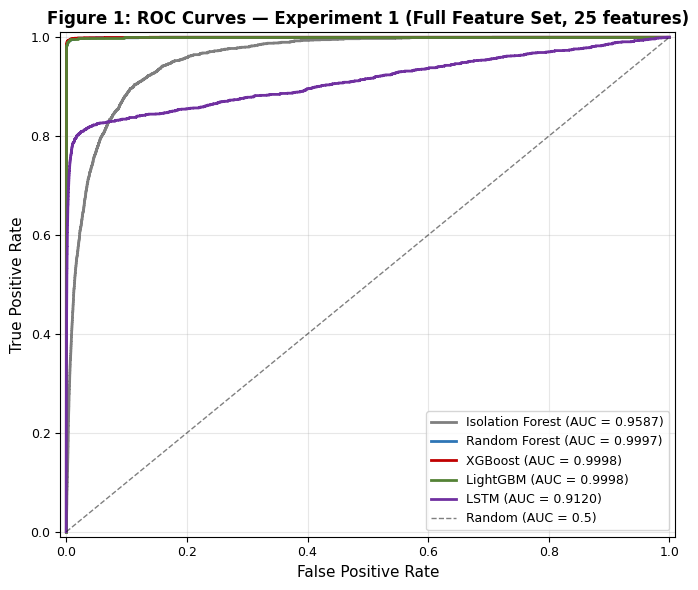

✅ Figure 1 saved


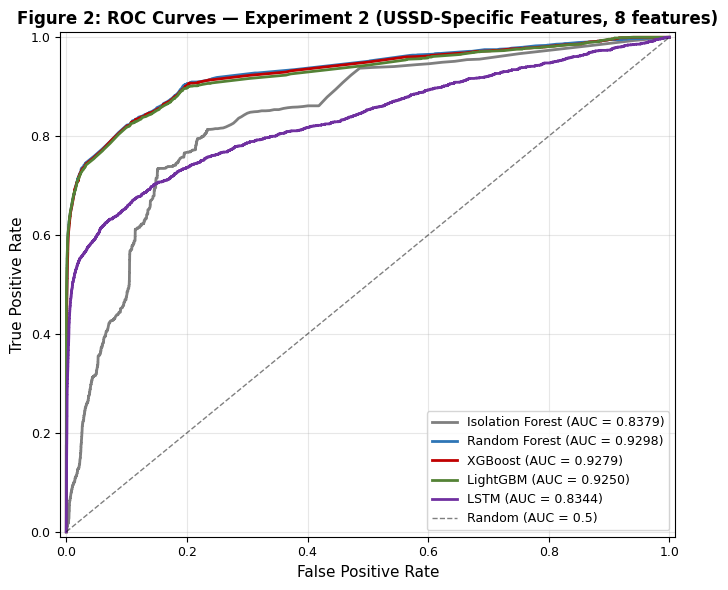

✅ Figure 2 saved


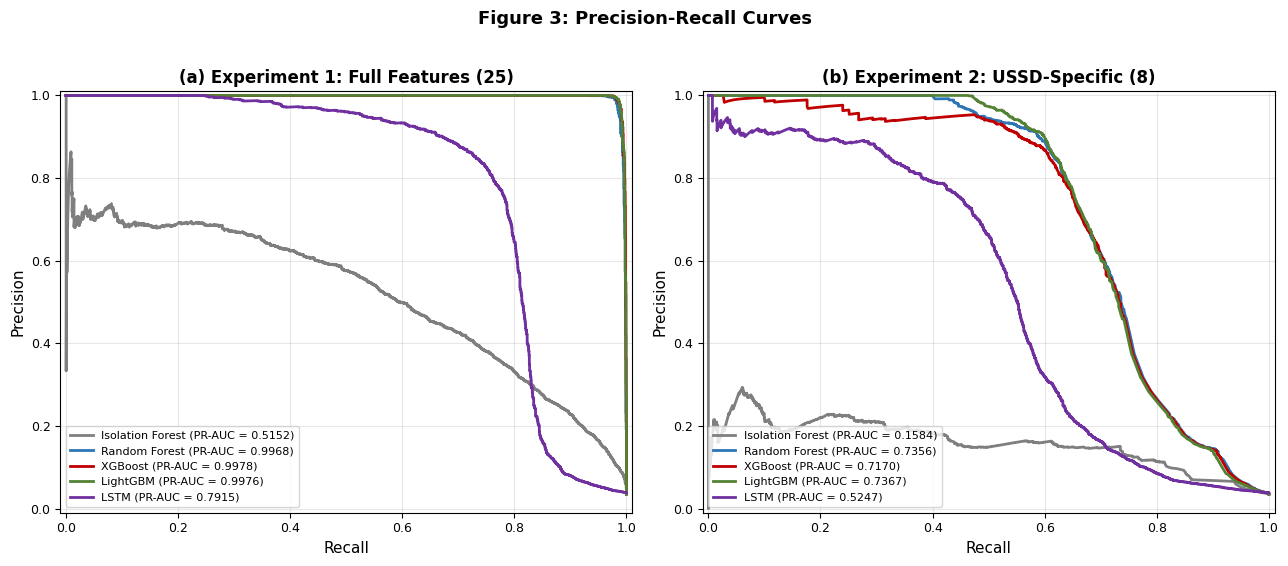

✅ Figure 3 saved


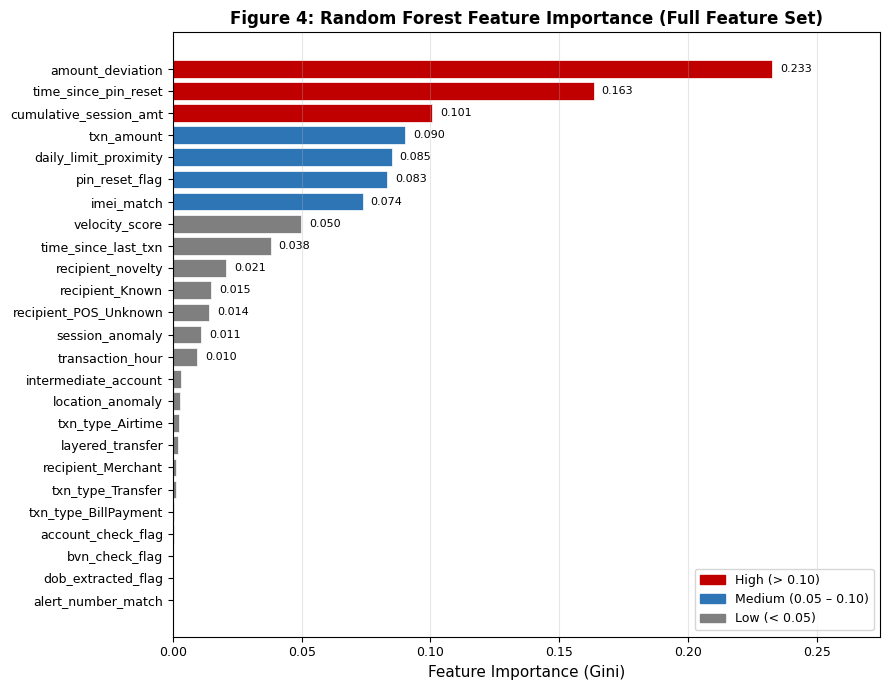

✅ Figure 4 saved


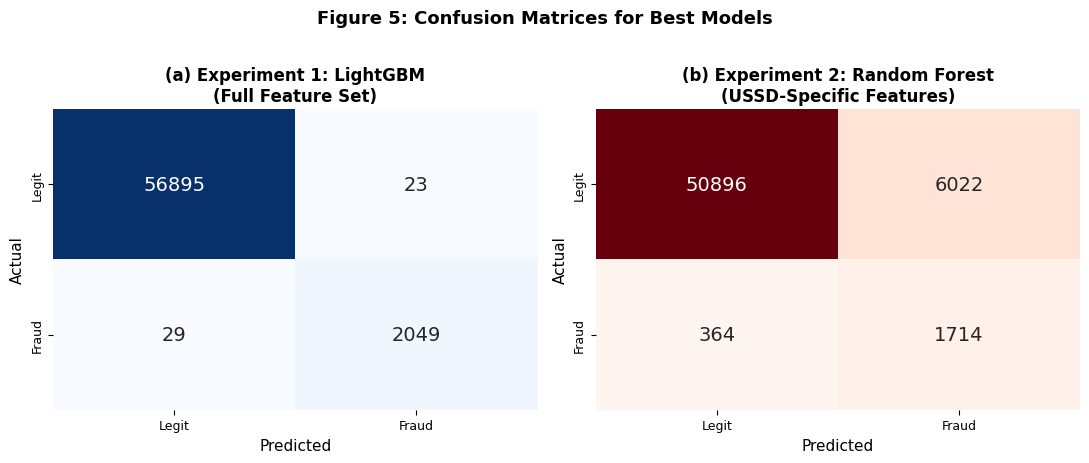

✅ Figure 5 saved


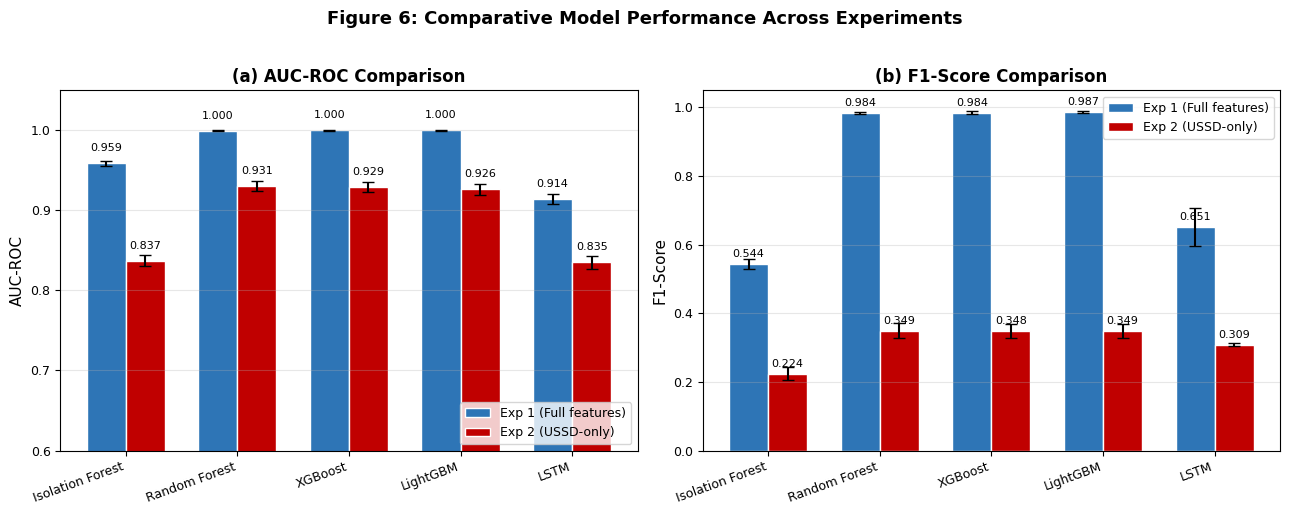

✅ Figure 6 saved

All 6 figures generated at 300 DPI
Files saved:
  - figure1_roc_experiment1.png
  - figure2_roc_experiment2.png
  - figure3_pr_curves.png
  - figure4_feature_importance.png
  - figure5_confusion_matrices.png
  - figure6_model_comparison.png


In [ ]:
 b    # ============================================
# Generates 6 figures at 300 DPI for Elsevier submission
# ============================================

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from sklearn.metrics import (roc_curve, precision_recall_curve,
                             auc, ConfusionMatrixDisplay)
import seaborn as sns

# Consistent styling
plt.rcParams.update({
    'font.family': 'sans-serif',
    'font.sans-serif': ['Arial', 'DejaVu Sans'],
    'font.size': 10,
    'axes.titlesize': 12,
    'axes.labelsize': 11,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'legend.fontsize': 9,
    'figure.dpi': 100,
    'savefig.dpi': 300,
    'savefig.bbox': 'tight',
})

# Color palette — colorblind-safe
MODEL_COLORS = {
    'Isolation Forest': '#7F7F7F',
    'Random Forest':    '#2E75B6',
    'XGBoost':          '#C00000',
    'LightGBM':         '#548235',
    'LSTM':             '#7030A0',
}
all_models = ['Isolation Forest', 'Random Forest', 'XGBoost', 'LightGBM', 'LSTM']

# ============================================
# We need fold-level y_true and y_prob to plot smooth curves
# ============================================
print("Collecting predictions for curve plots...")

def collect_curve_data(feature_cols, label):
    """Re-run CV but only collect y_true, y_prob per model."""
    X_data = df7[feature_cols].values
    y_data = df7['is_fraud'].values
    g_data = df7['user_id'].values
    gkf_c = GroupKFold(n_splits=N_FOLDS)

    # Tree models — collect ALL test fold predictions concatenated
    all_curves = {m: {'y_true': [], 'y_prob': []} for m in all_models}

    for tr_idx, te_idx in gkf_c.split(X_data, y_data, g_data):
        X_tr_raw, X_te_raw = X_data[tr_idx], X_data[te_idx]
        y_tr, y_te = y_data[tr_idx], y_data[te_idx]
        scaler_c = StandardScaler()
        X_tr_sc = scaler_c.fit_transform(X_tr_raw)
        X_te_sc = scaler_c.transform(X_te_raw)
        sm_c = SMOTE(random_state=42, k_neighbors=5)
        X_tr_bal, y_tr_bal = sm_c.fit_resample(X_tr_sc, y_tr)

        # IF
        iso = IsolationForest(contamination=max(y_tr.mean(),0.01),
                              n_estimators=200, max_samples=256,
                              random_state=42, n_jobs=-1)
        iso.fit(X_tr_sc)
        all_curves['Isolation Forest']['y_true'].extend(y_te)
        all_curves['Isolation Forest']['y_prob'].extend(-iso.score_samples(X_te_sc))

        # RF
        rf_c = RandomForestClassifier(n_estimators=200, max_depth=10,
            min_samples_leaf=5, min_samples_split=10, max_features='sqrt',
            random_state=42, n_jobs=-1)
        rf_c.fit(X_tr_bal, y_tr_bal)
        all_curves['Random Forest']['y_true'].extend(y_te)
        all_curves['Random Forest']['y_prob'].extend(rf_c.predict_proba(X_te_sc)[:,1])

        # XGB
        xgb_c = XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
            min_child_weight=5, gamma=0, reg_alpha=0.1, reg_lambda=1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            eval_metric='logloss', verbosity=0, n_jobs=-1)
        xgb_c.fit(X_tr_bal, y_tr_bal)
        all_curves['XGBoost']['y_true'].extend(y_te)
        all_curves['XGBoost']['y_prob'].extend(xgb_c.predict_proba(X_te_sc)[:,1])

        # LGB
        lgb_c = LGBMClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
            num_leaves=31, min_child_samples=20, reg_alpha=0.1, reg_lambda=1,
            subsample=0.8, colsample_bytree=0.8, random_state=42,
            verbosity=-1, n_jobs=-1)
        lgb_c.fit(X_tr_bal, y_tr_bal)
        all_curves['LightGBM']['y_true'].extend(y_te)
        all_curves['LightGBM']['y_prob'].extend(lgb_c.predict_proba(X_te_sc)[:,1])

    # LSTM — separate sequence pipeline
    X_seq, y_seq, uid_seq = make_user_sequences(df7_sorted, feature_cols, SEQ_LEN)
    gkf_l = GroupKFold(n_splits=N_FOLDS)
    for tr_idx, te_idx in gkf_l.split(X_seq, y_seq, uid_seq):
        X_tr, X_te = X_seq[tr_idx], X_seq[te_idx]
        y_tr_l, y_te_l = y_seq[tr_idx], y_seq[te_idx]
        ns_tr, sl_tr, nf_tr = X_tr.shape
        sc_l = StandardScaler()
        X_tr_sc = sc_l.fit_transform(X_tr.reshape(ns_tr*sl_tr, nf_tr)).reshape(ns_tr,sl_tr,nf_tr)
        X_te_sc = sc_l.transform(X_te.reshape(X_te.shape[0]*X_te.shape[1], nf_tr)).reshape(X_te.shape)
        cw = compute_class_weight('balanced', classes=np.unique(y_tr_l), y=y_tr_l)
        cw_dict = dict(enumerate(cw))
        tf.keras.backend.clear_session()
        np.random.seed(42); tf.random.set_seed(42)
        m = build_lstm(SEQ_LEN, nf_tr)
        es = EarlyStopping(monitor='val_auc', patience=5,
                          restore_best_weights=True, mode='max')
        m.fit(X_tr_sc, y_tr_l, epochs=30, batch_size=64,
              validation_split=0.1, class_weight=cw_dict,
              callbacks=[es], verbose=0)
        all_curves['LSTM']['y_true'].extend(y_te_l)
        all_curves['LSTM']['y_prob'].extend(m.predict(X_te_sc, verbose=0).flatten())

    print(f"  ✅ Predictions collected for {label}")
    return all_curves

curves_exp1 = collect_curve_data(all_feat_cols, "Experiment 1 (full features)")
curves_exp2 = collect_curve_data(ussd_specific_features, "Experiment 2 (USSD-only)")

# ============================================
# FIGURE 1 — ROC curves, Experiment 1
# ============================================
fig, ax = plt.subplots(figsize=(7, 6))
for m in all_models:
    fpr, tpr, _ = roc_curve(curves_exp1[m]['y_true'], curves_exp1[m]['y_prob'])
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=MODEL_COLORS[m], linewidth=2,
            label=f"{m} (AUC = {a:.4f})")
ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 1: ROC Curves — Experiment 1 (Full Feature Set, 25 features)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('figure1_roc_experiment1.png')
plt.show()
print("✅ Figure 1 saved")

# ============================================
# FIGURE 2 — ROC curves, Experiment 2
# ============================================
fig, ax = plt.subplots(figsize=(7, 6))
for m in all_models:
    fpr, tpr, _ = roc_curve(curves_exp2[m]['y_true'], curves_exp2[m]['y_prob'])
    a = auc(fpr, tpr)
    ax.plot(fpr, tpr, color=MODEL_COLORS[m], linewidth=2,
            label=f"{m} (AUC = {a:.4f})")
ax.plot([0,1], [0,1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.5)')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Figure 2: ROC Curves — Experiment 2 (USSD-Specific Features, 8 features)',
             fontweight='bold')
ax.legend(loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
plt.tight_layout()
plt.savefig('figure2_roc_experiment2.png')
plt.show()
print("✅ Figure 2 saved")

# ============================================
# FIGURE 3 — PR curves, both experiments side by side
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
for m in all_models:
    p, r, _ = precision_recall_curve(curves_exp1[m]['y_true'], curves_exp1[m]['y_prob'])
    pr_auc = auc(r, p)
    axes[0].plot(r, p, color=MODEL_COLORS[m], linewidth=2,
                 label=f"{m} (PR-AUC = {pr_auc:.4f})")
    p, r, _ = precision_recall_curve(curves_exp2[m]['y_true'], curves_exp2[m]['y_prob'])
    pr_auc = auc(r, p)
    axes[1].plot(r, p, color=MODEL_COLORS[m], linewidth=2,
                 label=f"{m} (PR-AUC = {pr_auc:.4f})")

for ax, title in zip(axes, ['(a) Experiment 1: Full Features (25)',
                            '(b) Experiment 2: USSD-Specific (8)']):
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(title, fontweight='bold')
    ax.legend(loc='lower left', fontsize=8)
    ax.grid(True, alpha=0.3)
    ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])

fig.suptitle('Figure 3: Precision-Recall Curves', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure3_pr_curves.png')
plt.show()
print("✅ Figure 3 saved")

# ============================================
# FIGURE 4 — Feature importance (Random Forest, full features)
# ============================================
scaler_fi = StandardScaler()
X_fi = scaler_fi.fit_transform(df7[all_feat_cols].values)
y_fi = df7['is_fraud'].values
rf_fi = RandomForestClassifier(n_estimators=200, max_depth=10,
    min_samples_leaf=5, random_state=42, n_jobs=-1)
rf_fi.fit(X_fi, y_fi)

fi_df = pd.DataFrame({
    'feature': all_feat_cols,
    'importance': rf_fi.feature_importances_
}).sort_values('importance', ascending=True)

colors_fi = ['#C00000' if imp > 0.10 else
             '#2E75B6' if imp > 0.05 else
             '#7F7F7F' for imp in fi_df['importance']]

fig, ax = plt.subplots(figsize=(9, 7))
bars = ax.barh(fi_df['feature'], fi_df['importance'], color=colors_fi,
               edgecolor='white', linewidth=0.5)
for bar, val in zip(bars, fi_df['importance']):
    if val > 0.005:
        ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center', fontsize=8)

ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Figure 4: Random Forest Feature Importance (Full Feature Set)',
             fontweight='bold')
high = mpatches.Patch(color='#C00000', label='High (> 0.10)')
med  = mpatches.Patch(color='#2E75B6', label='Medium (0.05 – 0.10)')
low  = mpatches.Patch(color='#7F7F7F', label='Low (< 0.05)')
ax.legend(handles=[high, med, low], loc='lower right')
ax.grid(True, axis='x', alpha=0.3)
ax.set_xlim(0, max(fi_df['importance']) * 1.18)
plt.tight_layout()
plt.savefig('figure4_feature_importance.png')
plt.show()
print("✅ Figure 4 saved")

# ============================================
# FIGURE 5 — Confusion matrices for best models
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

# Best Exp 1: LightGBM
y_true = np.array(curves_exp1['LightGBM']['y_true'])
y_prob = np.array(curves_exp1['LightGBM']['y_prob'])
y_pred = (y_prob > 0.5).astype(int)
cm1 = confusion_matrix(y_true, y_pred)
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            cbar=False, annot_kws={'size': 14},
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[0].set_xlabel('Predicted'); axes[0].set_ylabel('Actual')
axes[0].set_title('(a) Experiment 1: LightGBM\n(Full Feature Set)', fontweight='bold')

# Best Exp 2: Random Forest
y_true = np.array(curves_exp2['Random Forest']['y_true'])
y_prob = np.array(curves_exp2['Random Forest']['y_prob'])
y_pred = (y_prob > 0.5).astype(int)
cm2 = confusion_matrix(y_true, y_pred)
sns.heatmap(cm2, annot=True, fmt='d', cmap='Reds', ax=axes[1],
            cbar=False, annot_kws={'size': 14},
            xticklabels=['Legit', 'Fraud'], yticklabels=['Legit', 'Fraud'])
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')
axes[1].set_title('(b) Experiment 2: Random Forest\n(USSD-Specific Features)',
                  fontweight='bold')

fig.suptitle('Figure 5: Confusion Matrices for Best Models',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure5_confusion_matrices.png')
plt.show()
print("✅ Figure 5 saved")

# ============================================
# FIGURE 6 — Comparative bar chart: AUC & F1 across all models, both experiments
# ============================================
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

x = np.arange(len(all_models))
width = 0.35

# AUC subplot
auc_exp1 = [np.mean(fold_results[m]['auc']) for m in all_models]
auc_exp1_std = [np.std(fold_results[m]['auc']) for m in all_models]
auc_exp2 = [np.mean(fold_results_ussd[m]['auc']) for m in all_models]
auc_exp2_std = [np.std(fold_results_ussd[m]['auc']) for m in all_models]

b1 = axes[0].bar(x - width/2, auc_exp1, width, yerr=auc_exp1_std,
                 label='Exp 1 (Full features)', color='#2E75B6',
                 edgecolor='white', capsize=4)
b2 = axes[0].bar(x + width/2, auc_exp2, width, yerr=auc_exp2_std,
                 label='Exp 2 (USSD-only)', color='#C00000',
                 edgecolor='white', capsize=4)
axes[0].set_xticks(x)
axes[0].set_xticklabels(all_models, rotation=20, ha='right')
axes[0].set_ylabel('AUC-ROC')
axes[0].set_title('(a) AUC-ROC Comparison', fontweight='bold')
axes[0].set_ylim([0.6, 1.05])
axes[0].grid(True, axis='y', alpha=0.3)
axes[0].legend(loc='lower right')
for bar, val in zip(b1, auc_exp1):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.015,
                 f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(b2, auc_exp2):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.015,
                 f'{val:.3f}', ha='center', fontsize=8)

# F1 subplot
f1_exp1 = [np.mean(fold_results[m]['f1']) for m in all_models]
f1_exp1_std = [np.std(fold_results[m]['f1']) for m in all_models]
f1_exp2 = [np.mean(fold_results_ussd[m]['f1']) for m in all_models]
f1_exp2_std = [np.std(fold_results_ussd[m]['f1']) for m in all_models]

b3 = axes[1].bar(x - width/2, f1_exp1, width, yerr=f1_exp1_std,
                 label='Exp 1 (Full features)', color='#2E75B6',
                 edgecolor='white', capsize=4)
b4 = axes[1].bar(x + width/2, f1_exp2, width, yerr=f1_exp2_std,
                 label='Exp 2 (USSD-only)', color='#C00000',
                 edgecolor='white', capsize=4)
axes[1].set_xticks(x)
axes[1].set_xticklabels(all_models, rotation=20, ha='right')
axes[1].set_ylabel('F1-Score')
axes[1].set_title('(b) F1-Score Comparison', fontweight='bold')
axes[1].set_ylim([0, 1.05])
axes[1].grid(True, axis='y', alpha=0.3)
axes[1].legend(loc='upper right')
for bar, val in zip(b3, f1_exp1):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=8)
for bar, val in zip(b4, f1_exp2):
    axes[1].text(bar.get_x() + bar.get_width()/2, val + 0.02,
                 f'{val:.3f}', ha='center', fontsize=8)

fig.suptitle('Figure 6: Comparative Model Performance Across Experiments',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('figure6_model_comparison.png')
plt.show()
print("✅ Figure 6 saved")

print("\n" + "="*60)
print("All 6 figures generated at 300 DPI")
print("Files saved:")
print("  - figure1_roc_experiment1.png")
print("  - figure2_roc_experiment2.png")
print("  - figure3_pr_curves.png")
print("  - figure4_feature_importance.png")
print("  - figure5_confusion_matrices.png")
print("  - figure6_model_comparison.png")
print("="*60)

In [ ]:
print(feat_cols)

['transaction_hour', 'imei_match', 'location_anomaly', 'txn_amount', 'amount_deviation', 'recipient_novelty', 'velocity_score', 'time_since_last_txn', 'daily_limit_proximity', 'cumulative_session_amt', 'alert_number_match', 'account_check_flag', 'bvn_check_flag', 'dob_extracted_flag', 'pin_reset_flag', 'time_since_pin_reset', 'session_anomaly', 'intermediate_account', 'layered_transfer', 'recipient_Known', 'recipient_Merchant', 'recipient_POS_Unknown', 'txn_type_Airtime', 'txn_type_BillPayment', 'txn_type_Transfer']
